# Chapter 7: Measuring Fat with MRI

<a href="https://colab.research.google.com/github/choilab-jefferson/medimage/blob/main/Chapter07_MR_Fat_Quantification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

CT measures fat by brightness: adipose tissue sits between −190 and −30 HU, so you count pixels in
that range. Chapter 3 showed why the same trick fails on MRI — there is no calibrated scale, so a
brightness threshold means nothing.

MRI gets at fat a completely different way. Instead of asking *how bright is this pixel*, it uses
the fact that hydrogen atoms in fat and in water spin at slightly different rates, and lets the two
signals interfere. The answer comes out as a **proportion**, which is exactly the calibrated
quantity that raw MRI brightness lacks.

This chapter builds that measurement, finds where it breaks, and ends up somewhere narrower than
where it started.

By the end you will be able to:

1. Explain what in-phase and opposed-phase images are, and why two echo times are enough to separate
   fat from water.
2. Compute water and fat images, and a fat fraction map.
3. Derive why this particular fat fraction can never exceed 50%, and what that tells you about the
   method's limits.
4. Measure liver fat and compare it against the clinical threshold for fatty liver disease.
5. Say precisely what a research-grade PDFF measurement adds, and why CT is still the default for
   whole-body composition.

### Before you start

| | |
|---|---|
| **Builds on** | Chapter 3, especially Part B's point that MRI brightness is not a calibrated scale |
| **Downloads** | Several CHAOS T1-DUAL subjects, about 9 MB each |
| **Longest wait** | Section 4 fetches four more subjects from Zenodo, one file at a time. Give it a couple of minutes |
| **Beyond the setup cell** | Nothing extra to install |
| **Hardware** | Any laptop. No GPU needed |

If a download fails with **HTTP 429**, that is Zenodo rate-limiting the request, not a bug. The
loader retries with a growing delay and skips files it already has, so re-running the cell resumes
rather than restarting.

The physics in section 1 is the part to read slowly. Everything afterwards is arithmetic on two
images, and it will look arbitrary unless the reason there are exactly two is clear first.

## Setup

In [1]:
# --- Setup: Google Colab (primary) and local checkout (testing) ---------------
REPO_URL = "https://github.com/choilab-jefferson/medimage.git"
REPO_DIR = "medimage"

import os
import pathlib
import subprocess
import sys

try:
    import google.colab  # noqa: F401

    IN_COLAB = True
except ModuleNotFoundError:
    IN_COLAB = False

if IN_COLAB:
    # On Colab the repository is not present yet, so clone it and install the
    # few packages that are not part of the default runtime.
    if not pathlib.Path(REPO_DIR).is_dir():
        subprocess.run(["git", "clone", "--depth", "1", REPO_URL], check=True)
    os.chdir(REPO_DIR)
    subprocess.run(
        [sys.executable, "-m", "pip", "install", "-q", "pydicom", "remotezip"],
        check=True,
    )
else:
    # Locally the notebook already lives inside the repository; walk up until
    # we find the module that the notebooks import.
    root = pathlib.Path.cwd().resolve()
    while not (root / "medimage_data.py").is_file() and root != root.parent:
        root = root.parent
    os.chdir(root)

print("Running on Colab:", IN_COLAB)
print("Working directory:", pathlib.Path.cwd().name)

Running on Colab: False
Working directory: medimage


In [2]:
import numpy as np
import matplotlib.pyplot as plt

import medimage_data as md

in_phase, out_phase, reference, spacing = md.load_chaos(1)
in_phase = in_phase.astype(np.float32)
out_phase = out_phase.astype(np.float32)

dz, dy, dx = spacing
print("volume:", in_phase.shape)
print(f"voxel : {dz:.1f} x {dy:.2f} x {dx:.2f} mm")

volume: (35, 256, 256)
voxel : 5.5 x 1.89 x 1.89 mm


## 1. Why two echoes separate fat from water

A hydrogen atom in a fat molecule sits in a slightly different chemical environment from one in
water. That shifts how fast it precesses — by about 3.5 parts per million, which at 1.5 tesla works
out to roughly 220 cycles per second.

A small, constant difference in rate means the two signals drift in and out of step with each other.
Wait the right amount of time after exciting them and you can catch them either aligned or opposed:

- **In-phase (IP):** fat and water point the same way, so the signals add.
  $$\text{IP} = |\,W + F\,|$$
- **Opposed-phase (OP):** they point opposite ways, so the signals subtract.
  $$\text{OP} = |\,W - F\,|$$

At 1.5 T that happens at about 4.6 ms and 2.3 ms. Those are exactly the echo times in this dataset —
worth checking rather than assuming, since the whole method depends on it.

In [3]:
import pydicom

folder = md.fetch_chaos_t1dual(1, quiet=True) / "T1DUAL" / "DICOM_anon"
ip_header = pydicom.dcmread(sorted((folder / "InPhase").glob("*.dcm"))[0])
op_header = pydicom.dcmread(sorted((folder / "OutPhase").glob("*.dcm"))[0])

print(f"field strength   {ip_header.MagneticFieldStrength} T")
print(f"in-phase TE      {ip_header.EchoTime} ms")
print(f"opposed-phase TE {op_header.EchoTime} ms")

field strength   1.5 T
in-phase TE      4.635 ms
opposed-phase TE 2.302 ms


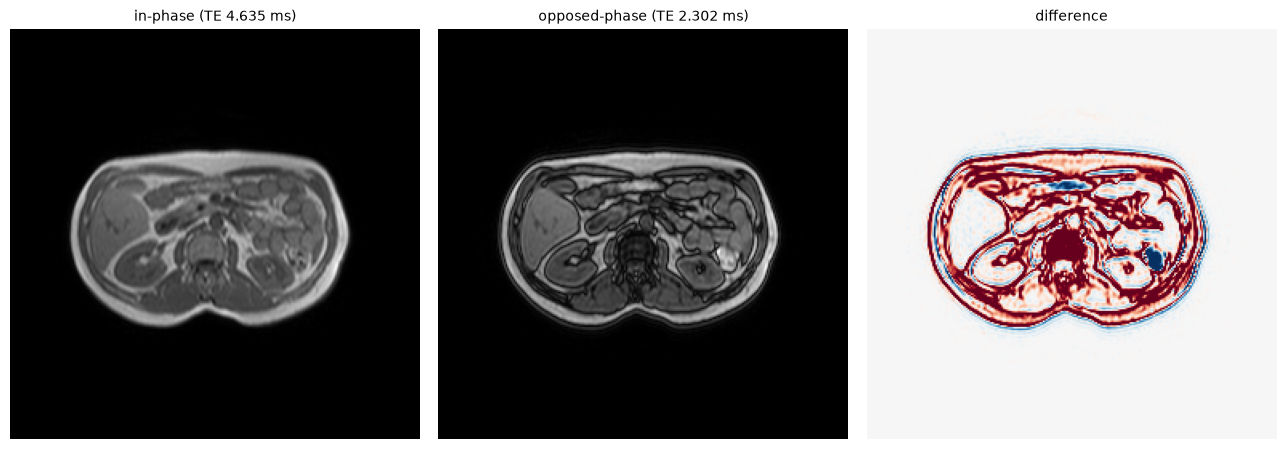

In [4]:
mid = in_phase.shape[0] // 2

fig, axes = plt.subplots(1, 3, figsize=(13, 4.4))
axes[0].imshow(in_phase[mid], cmap="gray")
axes[0].set_title(f"in-phase (TE {ip_header.EchoTime} ms)", fontsize=10)
axes[1].imshow(out_phase[mid], cmap="gray")
axes[1].set_title(f"opposed-phase (TE {op_header.EchoTime} ms)", fontsize=10)
axes[2].imshow(in_phase[mid] - out_phase[mid], cmap="RdBu_r", vmin=-200, vmax=200)
axes[2].set_title("difference", fontsize=10)
for ax in axes:
    ax.axis("off")
plt.tight_layout()
plt.show()

Look at the boundaries between organs and the fat around them in the opposed-phase image. They have
a dark outline that is not there in-phase. That black line is the giveaway: in a voxel containing
*both* fat and water, the two signals cancel. It is called the India-ink artifact, and it is the
effect this whole chapter is built on.

## 2. Recovering water and fat

Two equations, two unknowns. Add and subtract:

$$W = \frac{\text{IP} + \text{OP}}{2} \qquad F = \frac{\text{IP} - \text{OP}}{2}$$

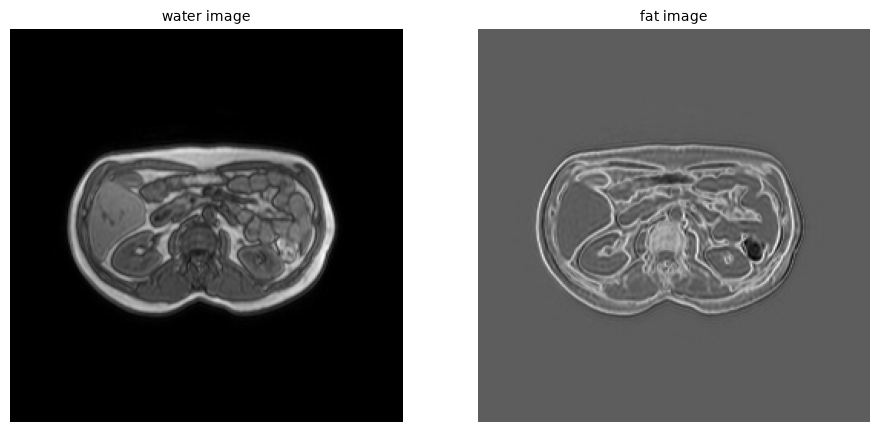

water range: 0.0 to 1037.0
fat range:   -263.5 to 407.5


In [5]:
water = (in_phase + out_phase) / 2
fat = (in_phase - out_phase) / 2

fig, axes = plt.subplots(1, 2, figsize=(9.5, 4.4))
axes[0].imshow(water[mid], cmap="gray")
axes[0].set_title("water image", fontsize=10)
axes[1].imshow(fat[mid], cmap="gray")
axes[1].set_title("fat image", fontsize=10)
for ax in axes:
    ax.axis("off")
plt.tight_layout()
plt.show()

print("water range:", water.min(), "to", water.max())
print("fat range:  ", fat.min(), "to", fat.max())

The fat image has **negative values**, which is physically impossible — you cannot have a negative
amount of fat. That is the first sign that something in the derivation does not hold everywhere.

## 3. Fat fraction, and a ceiling that should not be there

The quantity we actually want is a proportion: what share of the signal comes from fat?

$$\text{FF} = \frac{F}{W + F}$$

Now notice something. Substituting the definitions, $W + F$ is just the in-phase image:

$$W + F = \frac{\text{IP}+\text{OP}}{2} + \frac{\text{IP}-\text{OP}}{2} = \text{IP}$$

so

$$\text{FF} = \frac{(\text{IP} - \text{OP})/2}{\text{IP}}$$

Since OP is a magnitude and can never go below zero, **FF can never exceed 0.5**. Pure fat should
read 100%. This method cannot report more than 50% no matter what it is looking at.

In [6]:
signal = in_phase > 20                     # ignore background noise
fat_fraction = np.divide(in_phase - out_phase, 2 * in_phase,
                         out=np.zeros_like(in_phase), where=signal)

print(f"largest fat fraction found anywhere: {fat_fraction.max():.3f}")
print("(the algebra caps it at 0.500)")

largest fat fraction found anywhere: 0.500
(the algebra caps it at 0.500)


### Why it breaks: the fat–water swap

Work through what happens in pure subcutaneous fat, where there is no water at all ($W = 0$):

$$\text{IP} = |0 + F| = F \qquad \text{OP} = |0 - F| = F$$

The two images are **identical**. Feed that into the formulas and you get $F = 0$, $W = F$ — the
method reports pure fat as pure water.

Pure water does exactly the same thing, for the same reason. Because MRI records only the magnitude
of the signal and throws the sign away, there is no way to tell which of the two is the larger one.
The equations quietly assume water dominates, and wherever fat dominates, the labels swap.

So the fat image above is not a fat image. It is a map of *how mixed* each voxel is, and it peaks
where fat and water are half and half.

In [7]:
# Subcutaneous fat: bright on in-phase, and around the outside of the body.
edge = in_phase[mid] > 400
print("in a bright subcutaneous region, IP and OP should differ if the method worked:")
print(f"  mean IP  {in_phase[mid][edge].mean():7.1f}")
print(f"  mean OP  {out_phase[mid][edge].mean():7.1f}")
print(f"  reported fat fraction: {fat_fraction[mid][edge].mean():.3f}  <- should be near 1.0 for fat")

in a bright subcutaneous region, IP and OP should differ if the method worked:
  mean IP    565.6
  mean OP    411.9
  reported fat fraction: 0.142  <- should be near 1.0 for fat


## 4. Where the method genuinely works: liver fat

Everything above sounds like a failure, but this measurement is used clinically every day. The
reason is that its blind spot is at the extremes, and the clinical question sits in the middle.

**Hepatic steatosis** — fatty liver — is fat accumulating *inside* liver cells. The liver is mostly
water with a small and clinically important fat fraction: below 5% is normal, and above 5% is
steatosis. That is precisely the mixed regime where opposed-phase cancellation is strongest and the
formula behaves.

We have the radiologists' liver outlines from Chapter 3, so we can measure inside them directly.

In [8]:
liver = reference == 63
spleen = reference == 252

liver_ff = np.clip(fat_fraction[liver], 0, 0.5)
spleen_ff = np.clip(fat_fraction[spleen], 0, 0.5)

print(f"liver  mean fat fraction {liver_ff.mean():.1%}   median {np.median(liver_ff):.1%}")
print(f"spleen mean fat fraction {spleen_ff.mean():.1%}   median {np.median(spleen_ff):.1%}")
print()
print(f"IP -> OP signal drop in liver: {100 * (1 - out_phase[liver].mean() / in_phase[liver].mean()):.1f}%")

liver  mean fat fraction 2.9%   median 0.0%
spleen mean fat fraction 5.6%   median 1.1%

IP -> OP signal drop in liver: 3.9%


The spleen is there as a control. It contains essentially no fat, so whatever it reads is the
method's noise floor rather than a real measurement. Here it reads about as high as the liver does —
which means that for a liver this close to normal, the number is not distinguishable from noise.

That is a limitation worth stating plainly, and it is the reason research studies do not rely on
this two-point measurement when they need an accurate low fat fraction.

### Across several patients

The measurement earns its keep when the fat fraction is genuinely raised. Each subject below is a
separate download of a few megabytes, so this cell takes a couple of minutes the first time.

In [9]:
rows = []
for subject in [1, 2, 3, 5]:
    ip_s, op_s, ref_s, _ = md.load_chaos(subject)
    ip_s, op_s = ip_s.astype(np.float32), op_s.astype(np.float32)
    ff_s = np.divide(ip_s - op_s, 2 * ip_s, out=np.zeros_like(ip_s), where=ip_s > 20)
    values = np.clip(ff_s[ref_s == 63], 0, 0.5)
    rows.append((subject, values.mean(), np.median(values)))

print(f"{'subject':>8}{'mean FF':>10}{'median':>10}   interpretation")
for subject, mean_ff, median_ff in rows:
    verdict = "steatosis" if mean_ff >= 0.05 else "normal"
    print(f"{subject:>8}{mean_ff:>9.1%}{median_ff:>10.1%}   {verdict}")

print("\nclinical threshold: fat fraction of 5% or more indicates hepatic steatosis")

 subject   mean FF    median   interpretation
       1     2.9%      0.0%   normal
       2     3.7%      0.0%   normal
       3     6.8%      4.1%   steatosis
       5    24.8%     26.0%   steatosis

clinical threshold: fat fraction of 5% or more indicates hepatic steatosis


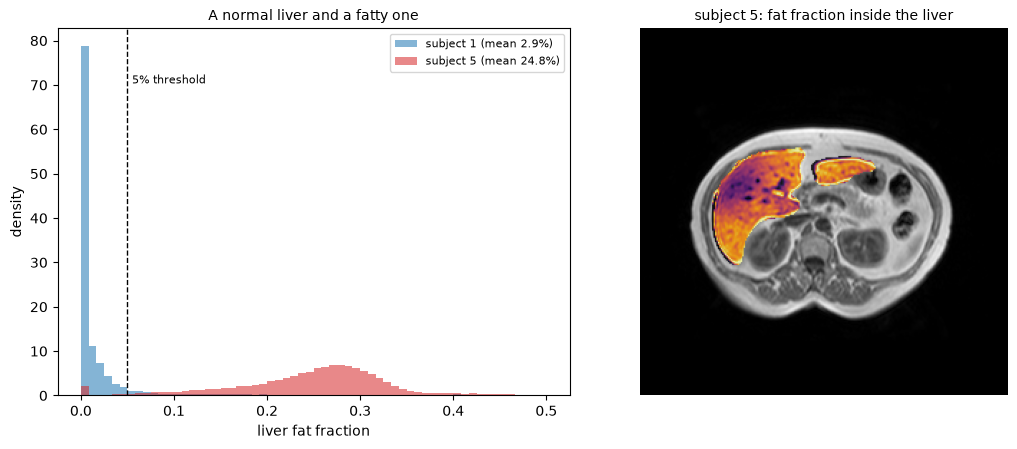

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.6))

for subject, color in [(1, "tab:blue"), (5, "tab:red")]:
    ip_s, op_s, ref_s, _ = md.load_chaos(subject)
    ip_s, op_s = ip_s.astype(np.float32), op_s.astype(np.float32)
    ff_s = np.divide(ip_s - op_s, 2 * ip_s, out=np.zeros_like(ip_s), where=ip_s > 20)
    values = np.clip(ff_s[ref_s == 63], 0, 0.5)
    axes[0].hist(values, bins=60, range=(0, 0.5), alpha=0.55,
                 label=f"subject {subject} (mean {values.mean():.1%})", color=color, density=True)

axes[0].axvline(0.05, color="black", linestyle="--", linewidth=1)
axes[0].text(0.055, axes[0].get_ylim()[1] * 0.85, "5% threshold", fontsize=8)
axes[0].set_xlabel("liver fat fraction")
axes[0].set_ylabel("density")
axes[0].set_title("A normal liver and a fatty one", fontsize=10)
axes[0].legend(fontsize=8)

ip_s, op_s, ref_s, _ = md.load_chaos(5)
ip_s, op_s = ip_s.astype(np.float32), op_s.astype(np.float32)
ff_s = np.divide(ip_s - op_s, 2 * ip_s, out=np.zeros_like(ip_s), where=ip_s > 20)
m = ip_s.shape[0] // 2
axes[1].imshow(ip_s[m], cmap="gray")
axes[1].imshow(np.where(ref_s[m] == 63, np.clip(ff_s[m], 0, 0.5), np.nan),
               cmap="inferno", vmin=0, vmax=0.4, alpha=0.85)
axes[1].set_title("subject 5: fat fraction inside the liver", fontsize=10)
axes[1].axis("off")

plt.tight_layout()
plt.show()

## 5. What a research-grade measurement adds

The quantity used in research and in drug trials is **PDFF** — proton density fat fraction. It is
the same idea taken seriously, and it fixes each of the problems above:

| Problem here | How PDFF fixes it |
|---|---|
| Only two echoes, so fat and water can swap | Six or more echoes, fitted jointly, which resolves which is which |
| Only magnitudes, so the sign is lost | Complex data, keeping the phase |
| Signal also decays from iron and other sources | T2\* estimated and corrected for |
| Fat treated as a single frequency | Fat modelled as its several real peaks |
| Cannot exceed 50% | Reports the full 0–100% range |

The result is accurate enough to be a trial endpoint, and it agrees closely with liver biopsy.

## 6. So why is Chapter 6 done on CT?

MRI has real advantages for fat: no ionizing radiation, and it can distinguish fat *quality*, not
just quantity. For measuring fat inside an organ, it is the better tool.

CT still wins for whole-body composition, for three practical reasons:

1. **The scans already exist.** Patients with cancer get CT routinely. Measuring body composition
   costs nothing extra, whereas a dedicated MRI has to be requested, scheduled and paid for.
2. **The scale is fixed.** Hounsfield units are anchored to water and air, so one threshold works
   everywhere. MRI needs a dedicated sequence before it produces a comparable number at all — which
   is the entire subject of this chapter.
3. **The reference values are CT-based.** The published cut-offs for low muscle mass are defined on
   CT at L3. A number measured differently cannot be compared against them.

None of this makes CT better. It makes CT *available*, which in clinical research is often the
deciding factor.

## Recap

| | |
|---|---|
| **Two echoes** | At the in-phase echo time the fat and water signals add; at the opposed-phase time they subtract. Two measurements, two unknowns |
| **Water and fat** | `water = (in + out) / 2`, `fat = (in − out) / 2` |
| **Fat fraction** | `fat / (fat + water)` — a *proportion*, which is the calibrated quantity raw MRI brightness lacks |
| **The 50% ceiling** | Only magnitudes are available, so the sign is lost. Above 50% fat, fat and water swap identities and the map folds back down instead of continuing up |
| **Where it works** | Liver fat, where the true fraction is far below the ceiling. Compared against the 5% clinical threshold for steatosis |
| **Where it does not** | Subcutaneous fat, which is nearly pure fat and therefore sits right where the method breaks |

The chapter's real shape is worth noticing: it starts out looking like a general fat-measurement
method and finishes as **a good liver measurement and a bad whole-body one**. The ceiling is not an
implementation flaw to be fixed by better code — it follows from having only magnitude images. That
is what research-grade PDFF buys with six echoes and complex data.

And this is why Chapter 6 is done on CT. Not because CT is better at fat — MRI has no radiation and
can see fat quality — but because the scans already exist, the scale is fixed, and the published
cut-offs are defined on CT at L3.

**Next:** Chapter 8 adds the third modality. PET measures how hard tissue is *working* rather than
where it is, and brings its own calibrated unit, SUV, which is the direct counterpart of the
Hounsfield unit.

## Exercises

1. Compute the fat fraction of the kidneys (labels 126 and 189) for subject 5. Are they raised like
   the liver, and would you expect them to be?

   *Hint:* reuse the liver cell with the label values swapped. Kidneys store far less fat than
   liver, so a high reading is a reason to suspect the measurement — check whether the region
   includes perirenal fat, which is nearly pure fat and sits against the ceiling.

2. Set the background cut-off `in_phase > 20` to 5 and to 100. How much does the liver fat fraction
   move? What does that say about how carefully the threshold has to be chosen?

   *Hint:* at 5 you admit background noise, where `fat + water` is near zero and the ratio explodes;
   at 100 you discard genuinely dark tissue. Print how many pixels survive each cut-off alongside
   the fraction.

3. Subject 5 reads about 25%. The method caps at 50%. How close to the ceiling would a liver have to
   be before you stopped trusting the number?

   *Hint:* there is no single right answer — argue it from the shape of the folding. Near 50% a
   large change in true fat produces almost no change in the measured value, so the measurement
   loses resolution well before it reaches the ceiling.

4. Using the spleen as a control, work out this method's noise floor across all four subjects. Below
   what fat fraction would you decline to report a result?

   *Hint:* the spleen should hold essentially no fat, so whatever it reads is your floor. This is
   the same control-organ logic Chapter 11 uses for delta radiomics — a measurement is only a
   finding if it is bigger than what the pipeline invents on something that did not change.

## References

- Dixon WT. *Simple proton spectroscopic imaging.* Radiology. 1984;153(1):189–194.
- Reeder SB, Hu HH, Sirlin CB. *Proton density fat-fraction: a standardized MR-based biomarker of
  tissue fat concentration.* J Magn Reson Imaging. 2012;36(5):1011–1014.
- Kavur AE, Gezer NS, Barış M, et al. *CHAOS Challenge — combined (CT-MR) healthy abdominal organ
  segmentation.* Medical Image Analysis. 2021;69:101950.
  [doi:10.1016/j.media.2020.101950](https://doi.org/10.1016/j.media.2020.101950)